# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.image import imread

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [107]:
image = imread("data/imagen.png")
image.shape

(500, 367, 4)

In [108]:
image = image[:, :, :3] 

In [109]:
shape_original = image.shape

In [110]:
shape_original

(500, 367, 3)

Muestra la imagen para ver que se ha cargado bien

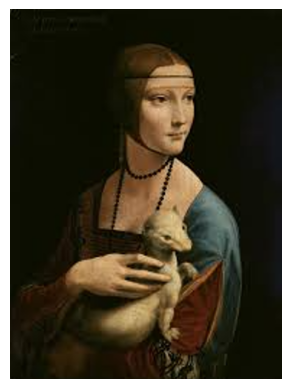

In [111]:
plt.imshow(image)
plt.axis('off') 
plt.show()

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [115]:
image_proc = image.reshape(-1,3)


In [116]:
X = image_proc
print(X.shape)

(183500, 3)


#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [152]:
kmeans = KMeans(n_clusters=10, n_init=10, random_state=11).fit(X)

In [153]:
kmeans.labels_.shape

(183500,)

In [154]:
kmeans.labels_

array([4, 8, 4, ..., 0, 0, 0], shape=(183500,), dtype=int32)

In [155]:
kmeans.cluster_centers_[kmeans.labels_]

array([[0.2135859 , 0.13050896, 0.04544127],
       [0.21306174, 0.26034874, 0.22621442],
       [0.2135859 , 0.13050896, 0.04544127],
       ...,
       [0.0525226 , 0.05720261, 0.00944782],
       [0.0525226 , 0.05720261, 0.00944782],
       [0.0525226 , 0.05720261, 0.00944782]],
      shape=(183500, 3), dtype=float32)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [156]:
centroids = kmeans.cluster_centers_

labels = kmeans.labels_

img_segmented = (centroids[labels] * 255).reshape(image.shape).astype(np.uint8)

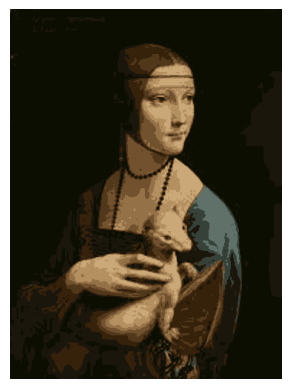

In [157]:
plt.imshow(img_segmented)
plt.axis('off')  # opcional, para quitar ejes
plt.show()

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [158]:
shape_original

(500, 367, 3)

In [161]:
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
img_reconstructed = (centroids[labels] * 255).reshape(shape_original).astype(np.uint8)

In [163]:
img_reconstructed.shape

(500, 367, 3)

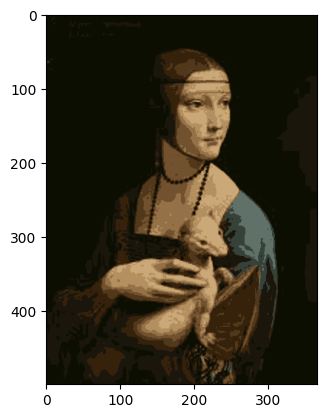

In [162]:
plt.imshow(img_reconstructed)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

In [164]:
plt.imsave("data/imagen_nueva.png", img_reconstructed)

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [165]:
def procesar_imagen(ruta_imagen: str, colores: int, guardar: str = "no", mostrar: str = "no"):

    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.cluster import KMeans
    from matplotlib.image import imread
    import os

    image = imread(ruta_imagen)
    image = image[:, :, :3]  
    shape_original = image.shape

    X = image.reshape(-1, 3)

    kmeans = KMeans(n_clusters=colores, n_init=10, random_state=11)
    kmeans.fit(X)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_

    if image.dtype != np.uint8:
        img_reconstructed = (centroids[labels] * 255).reshape(shape_original).astype(np.uint8)
    else:
        img_reconstructed = centroids[labels].reshape(shape_original).astype(np.uint8)

    if mostrar.lower() == "si":
        plt.imshow(img_reconstructed)
        plt.axis('off')
        plt.show()

    if guardar.lower() == "si":

        dir_name = os.path.dirname(ruta_imagen)
        archivo_salida = os.path.join(dir_name, "imagen_segmentada.png")
        plt.imsave(archivo_salida, img_reconstructed)
        print(f"Imagen guardada en: {archivo_salida}")

    return img_reconstructed
            


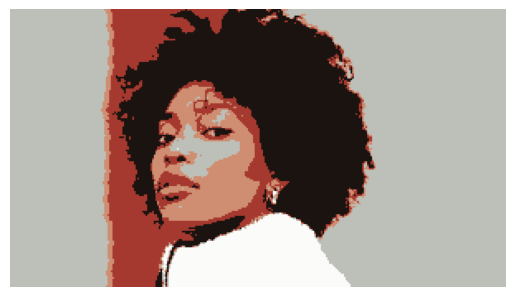

Imagen guardada en: C:\Users\Administrador\Desktop\repositorios_agc\repo_agc\ONLINE_DS_THEBRIDGE_TRABAJOSAGC\3-Machine_Learning\2-No_Supervisado\1-Clustering\Practica\data\imagen_segmentada.png


array([[[189, 191, 185],
        [189, 191, 185],
        [189, 191, 185],
        ...,
        [189, 191, 185],
        [189, 191, 185],
        [189, 191, 185]],

       [[189, 191, 185],
        [189, 191, 185],
        [189, 191, 185],
        ...,
        [189, 191, 185],
        [189, 191, 185],
        [189, 191, 185]],

       [[189, 191, 185],
        [189, 191, 185],
        [189, 191, 185],
        ...,
        [189, 191, 185],
        [189, 191, 185],
        [189, 191, 185]],

       ...,

       [[189, 191, 185],
        [189, 191, 185],
        [189, 191, 185],
        ...,
        [189, 191, 185],
        [189, 191, 185],
        [189, 191, 185]],

       [[189, 191, 185],
        [189, 191, 185],
        [189, 191, 185],
        ...,
        [189, 191, 185],
        [189, 191, 185],
        [189, 191, 185]],

       [[189, 191, 185],
        [189, 191, 185],
        [189, 191, 185],
        ...,
        [189, 191, 185],
        [189, 191, 185],
        [189, 191, 185]]

In [167]:
procesar_imagen(r"C:\Users\Administrador\Desktop\repositorios_agc\repo_agc\ONLINE_DS_THEBRIDGE_TRABAJOSAGC\3-Machine_Learning\2-No_Supervisado\1-Clustering\Practica\data\descarga.jpg", 5, "si", "si")